# Temas Tratados en el Trabajo Práctico 3

* Estrategias de búsqueda local.

* Algoritmos Evolutivos.

* Problemas de Satisfacción de Restricciones.

# Ejercicios Teóricos

1. ¿Qué mecanismo de detención presenta el algoritmo de Ascensión de Colinas? Describa el problema que puede presentar este mecanismo y cómo se llaman las áreas donde ocurren estos problemas.


2. Describa las distintas heurísticas que se emplean en un problema de Satisfacción de Restricciones.

3. Se desea colorear el rompecabezas mostrado en la imagen con 7 colores distintos de manera que ninguna pieza tenga el mismo color que sus vecinas. Realice en una tabla el proceso de una búsqueda con Comprobación hacia Adelante empleando una heurística del Valor más Restringido.

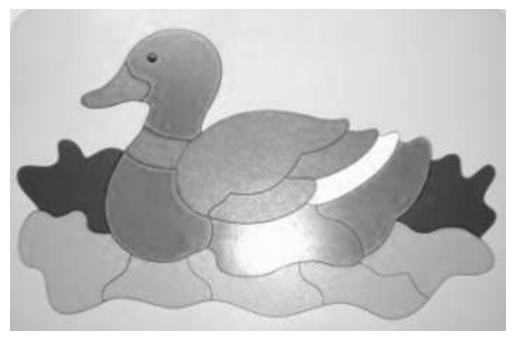

In [2]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1j94jFVxVG9y_ZnrMWOscQGb2MZ0Cdb3R"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

# Ejercicios de Implementación

4. Encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$ utilizando el algoritmo _hill climbing_.

##### Prompt utilizado

Eres un ingeniero especializado en ia utilizando el algoritmo hill climbing aplicado a las matemáticas, realiza un algoritmo que encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$,

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    """Función objetivo a maximizar."""
    # Usamos np.sin para que funcione tanto con números sueltos como con arrays para el gráfico
    return np.sin(x) / (x + 0.1)

def hill_climbing_continuo(dominio, paso):
    # 1. Estado inicial aleatorio
    x_actual = random.uniform(dominio[0], dominio[1])
    y_actual = f(x_actual)
    
    # Guardamos el punto de inicio para mostrarlo en el gráfico
    x_inicio = x_actual 
    y_inicio = y_actual
    
    iteraciones = 0
    
    while True:
        iteraciones += 1
        
        # 2. Generar vecindad
        x_izq = x_actual - paso
        x_der = x_actual + paso
        
        # 3. Evaluar vecinos (penalizando con -infinito si salen del dominio)
        y_izq = f(x_izq) if x_izq >= dominio[0] else float('-inf')
        y_der = f(x_der) if x_der <= dominio[1] else float('-inf')
        
        # 4. Transición
        if y_izq > y_der and y_izq > y_actual:
            x_actual = x_izq
            y_actual = y_izq
        elif y_der > y_izq and y_der > y_actual:
            x_actual = x_der
            y_actual = y_der
        else:
            # 5. Condición de parada
            break
            
    return x_actual, y_actual, x_inicio, y_inicio

# --- PARÁMETROS ---
dominio_x = [-10, -6]
error_maximo = 0.01 

# --- EJECUCIÓN ---
mejor_x, max_f, x_ini, y_ini = hill_climbing_continuo(dominio_x, error_maximo)

print(f"Punto de inicio : x = {x_ini:.4f}, f(x) = {y_ini:.4f}")
print(f"Máximo hallado  : x = {mejor_x:.4f}, f(x) = {max_f:.4f}")

# --- GRAFICACIÓN ---
# 1. Crear un conjunto de puntos para dibujar la curva suave
x_curva = np.linspace(dominio_x[0], dominio_x[1], 500)
y_curva = f(x_curva)

# 2. Configurar el lienzo
plt.figure(figsize=(10, 6))

# 3. Dibujar la función
plt.plot(x_curva, y_curva, label='f(x) = sin(x) / (x + 0.1)', color='blue', linewidth=2)

# 4. Dibujar el punto de inicio (Gris) y el máximo encontrado (Rojo)
plt.plot(x_ini, y_ini, 'o', color='gray', markersize=8, label=f'Inicio ({x_ini:.2f}, {y_ini:.2f})')
plt.plot(mejor_x, max_f, 'ro', markersize=10, label=f'Máximo ({mejor_x:.2f}, {max_f:.2f})')

# 5. Detalles estéticos del gráfico
plt.title('Búsqueda del Máximo mediante Hill Climbing')
plt.xlabel('Eje X')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 6. Mostrar el gráfico
plt.show()

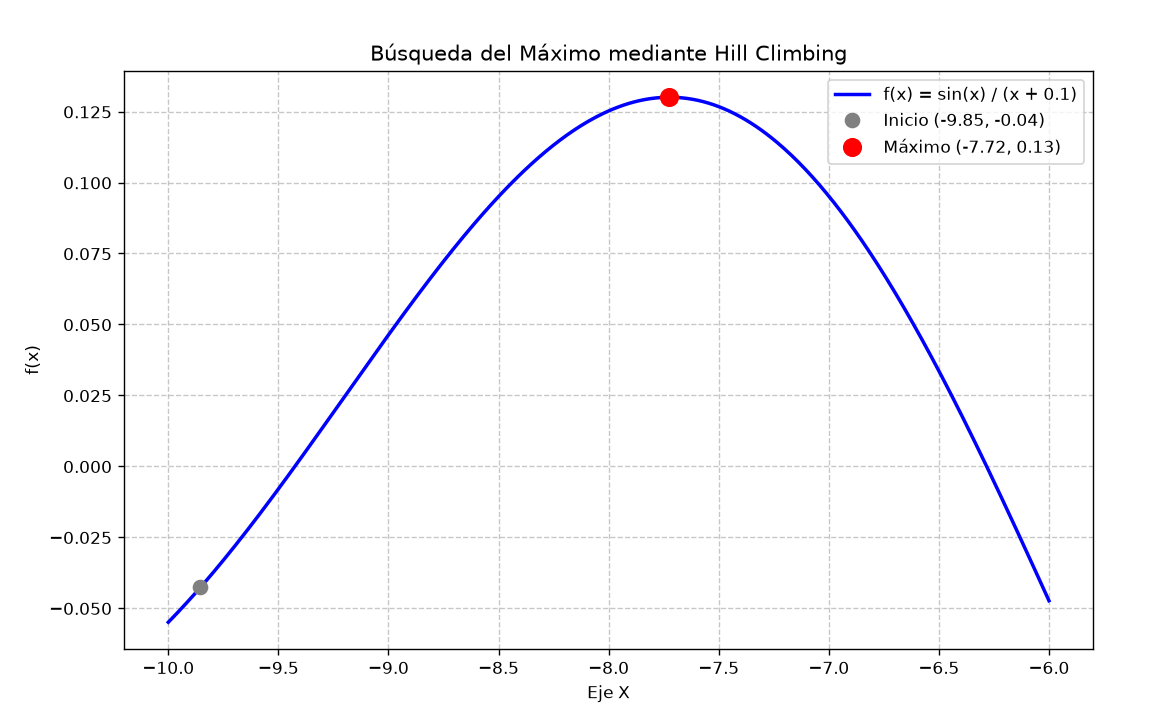

5. Diseñe e implemente un algoritmo de Recocido Simulado para que juegue contra usted al Ta-te-ti. Varíe los valores de temperatura inicial entre partidas, ¿qué diferencia observa cuando la temperatura es más alta con respecto a cuando la temperatura es más baja?


6. Diseñe e implemente un algoritmo genético para cargar una grúa con $n=10\;cajas$ que puede soportar un peso máximo $C=1000\;kg$. Cada caja *j* tiene asociado un precio $p_j$ y un peso $w_j$ como se indica en la tabla de abajo, de manera que el algoritmo debe ser capaz de maximizar el precio sin superar el límite de carga.

<table><tr><td>Elemento ($j$)</td><td>1</td><td>2</td><td>3</td><td>4</td><td>5</td><td>6</td><td>7</td><td>8</td><td>9</td><td>10</td></tr>

<tr><td>Precio ($p_j$)</td><td>100</td><td>50</td><td>115</td><td>25</td><td>200</td><td>30</td><td>40</td><td>100</td><td>100</td><td>100</td></tr>

<tr><td>Peso ($w_j$)</td><td>300</td><td>200</td><td>450</td><td>145</td><td>664</td><td>90</td><td>150</td><td>355</td><td>401</td><td>395</td></tr></table><br>

        6.1 En primer lugar, es necesario representar qué cajas estarán cargadas en la grúa y cuáles no. Esta representación corresponde a un Individuo con el que trabajará el algoritmo.

        6.2 A continuación, genere una Población que contenga un número $N$ de individuos (se recomienda elegir un número par). Es necesario crear un control que verifique que ninguno de los individuos supere el peso límite.

        6.3 Cree ahora una función que permita evaluar la Idoneidad de cada individuo y seleccione $N/2$ parejas usando el método de la ruleta.

        6.4 Por último, Cruce las parejas elegidas, aplique un mecanismo de Mutación y verifique que los individuos de la nueva población no superen el límite de peso.

        6.5 Realice este proceso iterativamente hasta que se cumpla el mecanismo de detención de su elección y muestre el mejor individuo obtenido junto con el peso y el precio que alcanza.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)